[![Colab Badge](https://img.shields.io/badge/Open_in_Colab-blue?style=for-the-badge)][colab-link]
<a href="javascript:void(0);" onclick="openJupyterWidget('https://github.com/nmfs-opensci/nmfshackdays-2025/blob/main/topics-2025/2025-PACE/pace-avw.ipynb');">
    <img src="https://img.shields.io/badge/Open_in_JupyterHub-orange?style=for-the-badge" alt="JupyterHub Badge">
</a> [![Download Badge](https://img.shields.io/badge/Download-grey?style=for-the-badge)][download-link]

[download-link]: https://nmfs-opensci.github.io/NMFSHackDays-2025/topics-2025/2025-PACE/pace-avw.ipynb
[colab-link]: https://colab.research.google.com/github/nmfs-opensci/nmfshackdays-2025/blob/main/topics-2025/2025-PACE/pace-avw.ipynb
[jupyter-link]: https://nmfs-openscapes.2i2c.cloud/hub/user-redirect/lab?fromURL=https://raw.githubusercontent.com/nmfs-opensci/nmfshackdays-2025/main/topics-2025/2025-PACE/pace-avw.ipynb

## Overview

The figures were generated from Level 2 products.

The PACE Level-2 OCI (ocean color instrument) data is available on an NASA EarthData. Search using the instrument filter "OCI" and processing level 2 filter <https://search.earthdata.nasa.gov/search?fi=OCI&fl=2%2B-%2BGeophys.%2BVariables%252C%2BSensor%2BCoordinates> and you will see 16 data collections. 

## Datasets used

#### PACE OCI Level-2 Regional Apparent Optical Properties Data, version 3.0
* https://cmr.earthdata.nasa.gov/search/concepts/C3385049983-OB_CLOUD.html
* remote sensing reflectance and avw
* short name: PACE_OCI_L2_AOP
* date: 2024-05-13
* spatial bin: T171853
* spatial extent: lat=[38.0,42.5]; lon=[-75.5,-69.0];
* filename: PACE_OCI.20240513T171853.L2.OC_AOP.V3_0_0.nc
      

### Prerequisites

You need to have an EarthData Login username and password. Go here to get one <https://urs.earthdata.nasa.gov/>

I assume you have a `.netrc` file at `~` (home). `~/.netrc` should look just like this with your username and password. Create that file if needed. You don't need to create it if you don't have this file. The `earthaccess.login(persist=True)` line will ask for your username and password and create the `.netrc` file for you.

```
machine urs.earthdata.nasa.gov
        login yourusername
        password yourpassword
```

#### For those not working in the JupyterHub

Uncomment this and run the cell:


In [1]:
# pip install earthaccess

## Rrs figures

### Get and set up data

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

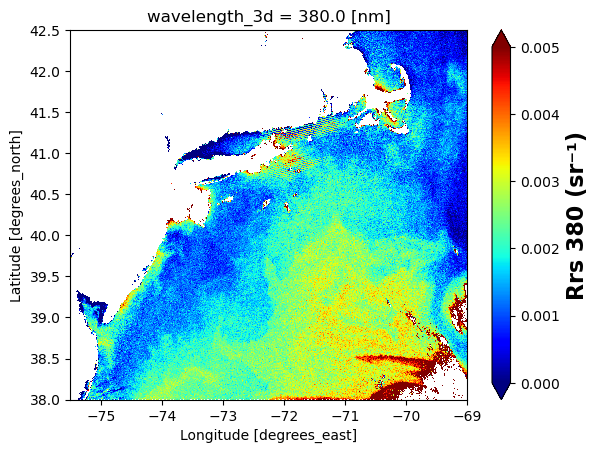

CPU times: user 14.1 s, sys: 6.35 s, total: 20.5 s
Wall time: 1min 2s


In [1]:
%%time
# Authenticate to NASA
import earthaccess
auth = earthaccess.login(strategy="interactive", persist=True)
    
# (xmin=-73.5, ymin=33.5, xmax=-43.5, ymax=43.5)
bbox = (-75.5, 38.0, -69.0, 42.5)
import earthaccess
results = earthaccess.search_data(
    short_name = "PACE_OCI_L2_AOP",
    temporal = ("2024-05-13", "2024-05-13"),
    bounding_box = bbox
)
fileset = earthaccess.open(results);

# load data
import xarray as xr
ds = xr.open_dataset(fileset[0], group="geophysical_data")

# Add coords
# Add coords
nav = xr.open_dataset(fileset[0], group="navigation_data")
nav = nav.set_coords(("longitude", "latitude"))
wave = xr.open_dataset(fileset[0], group="sensor_band_parameters")
wave = wave.set_coords(("wavelength_3d"))
dataset = xr.merge((ds["Rrs"], nav.coords, wave.coords))

# Subset
rrs_box = dataset.where(
    (
        (dataset["latitude"] > 38.0)
        & (dataset["latitude"] < 42.5)
        & (dataset["longitude"] > -75.5)
        & (dataset["longitude"] < -69.0)
    ),
    drop = True
)

### Make plots

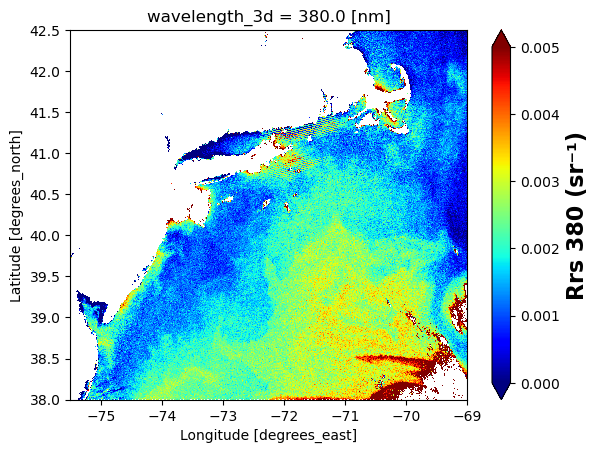

In [10]:
# make single plot
import matplotlib.pyplot as plt

rrs = rrs_box["Rrs"].sel(wavelength_3d = 380)
plot = rrs.plot(x="longitude", y="latitude", cmap="jet", vmin=0, vmax=0.005)

# Set x and y limits
plot.axes.set_xlim(-75.5, -69.0)
plot.axes.set_ylim(38.0, 42.5)

# Customize colorbar label
wave_string = "380"  # or str(wavelength) if dynamic
plot.colorbar.set_label(f"Rrs {wave_string} (sr⁻¹)", fontsize=16, fontweight="bold")

plt.show()

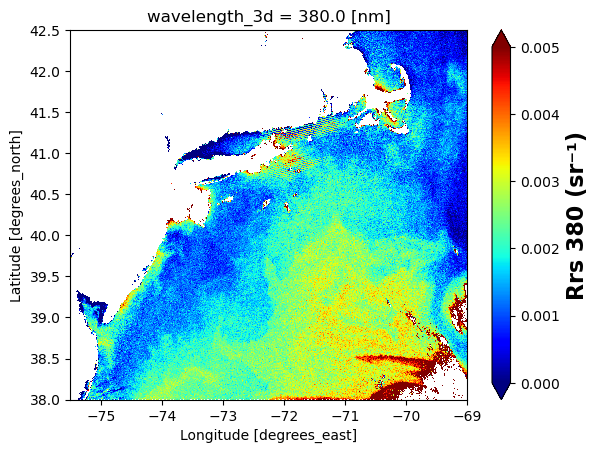

In [11]:
# make multiple plots
import matplotlib.pyplot as plt

rrs = rrs_box["Rrs"].sel(wavelength_3d = 380)
plot = rrs.plot(x="longitude", y="latitude", cmap="jet", vmin=0, vmax=0.005)

# Set x and y limits
plot.axes.set_xlim(-75.5, -69.0)
plot.axes.set_ylim(38.0, 42.5)

# Customize colorbar label
wave_string = "380"  # or str(wavelength) if dynamic
plot.colorbar.set_label(f"Rrs {wave_string} (sr⁻¹)", fontsize=16, fontweight="bold")

plt.show()

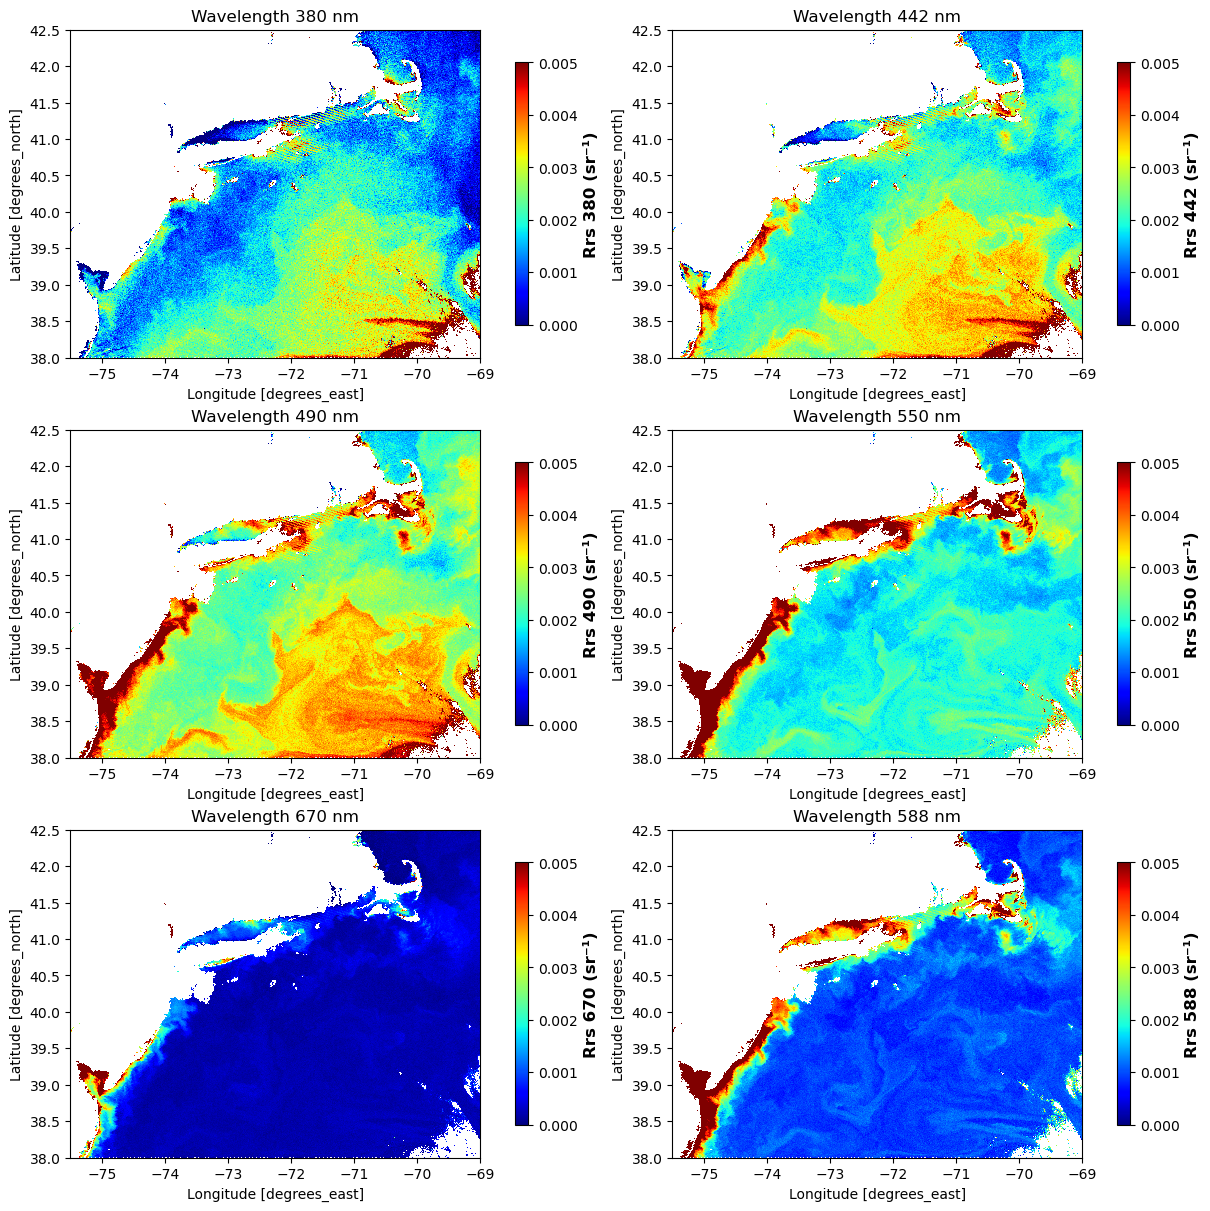

In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# List of wavelengths to plot
wavelengths = [380, 442, 490, 550, 670, 588]

# Create figure and axes
fig, axes = plt.subplots(3, 2, figsize=(12, 12), constrained_layout=True)
axes = axes.flatten()

# Loop through wavelengths and plot
for i, wl in enumerate(wavelengths):
    ax = axes[i]
    
    # Extract Rrs and mask zeros (for log or safety)
    rrs = rrs_box["Rrs"].sel(wavelength_3d=wl)
    
    # Plot onto the provided axis
    img = rrs.plot(
        ax=ax,
        x="longitude",
        y="latitude",
        cmap="jet",
        vmin=0,
        vmax=0.005,
        add_colorbar=False  # We'll add our own
    )
    
    # Set limits
    ax.set_xlim(-75.5, -69.0)
    ax.set_ylim(38.0, 42.5)
    
    # Add colorbar
    cbar = fig.colorbar(img, ax=ax, orientation="vertical", shrink=0.8)
    cbar.set_label(f"Rrs {wl} (sr⁻¹)", fontsize=12, fontweight="bold")
    
    # Optional: title or annotation
    ax.set_title(f"Wavelength {wl} nm")

# Turn off unused axes (if any)
for j in range(len(wavelengths), len(axes)):
    fig.delaxes(axes[j])

plt.show()


## AVW figures

### Get and set up data

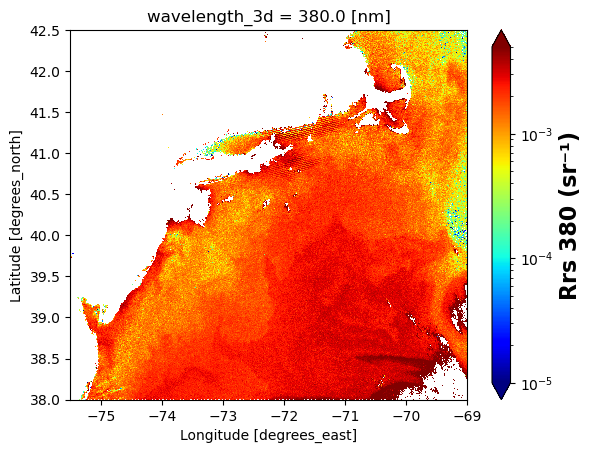

## Rrs plot

I poked around on the files on [search.earthdata](https://search.earthdata.nasa.gov/search/granules/collection-details?p=C3385050418-OB_CLOUD&pg[0][v]=f&pg[0][gsk]=-start_date&fi=OCI&fl=3%2B-%2BGridded%2BObservations&tl=1726833236.2!4!!&lat=0.0703125) so I know what the files look like.

In [2]:
# (xmin=-73.5, ymin=33.5, xmax=-43.5, ymax=43.5)
bbox = (-75.5, 38.0, -69.0, 42.5)
import earthaccess
results = earthaccess.search_data(
    short_name = "PACE_OCI_L2_AOP",
    temporal = ("2024-05-13", "2024-05-13"),
    bounding_box = bbox
)
len(results)

1

In [7]:
results[0]

Collection: {'ShortName': 'PACE_OCI_L2_AOP', 'Version': '3.0'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 44.91945, 'Longitude': -57.21905}, {'Latitude': 39.10262, 'Longitude': -89.05525}, {'Latitude': 16.69017, 'Longitude': -79.84663}, {'Latitude': 21.74278, 'Longitude': -54.86623}, {'Latitude': 44.91945, 'Longitude': -57.21905}]}}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2024-05-13T17:18:53Z', 'EndingDateTime': '2024-05-13T17:23:52Z'}}
Size(MB): 405.2006778717041
Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240513T171853.L2.OC_AOP.V3_0.nc']

In [3]:
# Create a fileset
fileset = earthaccess.open(results);

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

In [27]:
# load metadata
import xarray as xr
ds = xr.open_dataset(fileset[0], group="geophysical_data")
rrs = ds["Rrs"]
rrs

<xarray.DataArray 'Rrs' (number_of_lines: 1709, pixels_per_line: 1272,
                         wavelength_3d: 172)> Size: 1GB
[373901856 values with dtype=float32]
Dimensions without coordinates: number_of_lines, pixels_per_line, wavelength_3d
Attributes:
    long_name:      Remote sensing reflectance
    units:          sr^-1
    standard_name:  surface_ratio_of_upwelling_radiance_emerging_from_sea_wat...
    valid_min:      -30000
    valid_max:      25000

In [26]:
import h5netcdf
with h5netcdf.File(fileset[0]) as file:
    groups = list(file)
groups

['sensor_band_parameters',
 'scan_line_attributes',
 'geophysical_data',
 'navigation_data',
 'processing_control']

In [28]:
# Add coords
nav = xr.open_dataset(fileset[0], group="navigation_data")
nav = nav.set_coords(("longitude", "latitude"))
wave = xr.open_dataset(fileset[0], group="sensor_band_parameters")
wave = wave.set_coords(("wavelength_3d"))
dataset = xr.merge((rrs, nav.coords, wave.coords))
dataset

<xarray.Dataset> Size: 2GB
Dimensions:        (number_of_lines: 1709, pixels_per_line: 1272,
                    wavelength_3d: 172)
Coordinates:
  * wavelength_3d  (wavelength_3d) float64 1kB 346.0 348.0 351.0 ... 717.0 719.0
    longitude      (number_of_lines, pixels_per_line) float32 9MB ...
    latitude       (number_of_lines, pixels_per_line) float32 9MB ...
Dimensions without coordinates: number_of_lines, pixels_per_line
Data variables:
    Rrs            (number_of_lines, pixels_per_line, wavelength_3d) float32 1GB ...
Attributes:
    long_name:      Remote sensing reflectance
    units:          sr^-1
    standard_name:  surface_ratio_of_upwelling_radiance_emerging_from_sea_wat...
    valid_min:      -30000
    valid_max:      25000

In [8]:
rrs = ds["Rrs"]
print(rrs)

<xarray.DataArray 'Rrs' (number_of_lines: 1709, pixels_per_line: 1272,
                         wavelength_3d: 172)> Size: 1GB
[373901856 values with dtype=float32]
Coordinates:
    longitude  (number_of_lines, pixels_per_line) float32 9MB ...
    latitude   (number_of_lines, pixels_per_line) float32 9MB ...
Dimensions without coordinates: number_of_lines, pixels_per_line, wavelength_3d
Attributes:
    long_name:      Remote sensing reflectance
    units:          sr^-1
    standard_name:  surface_ratio_of_upwelling_radiance_emerging_from_sea_wat...
    valid_min:      -30000
    valid_max:      25000


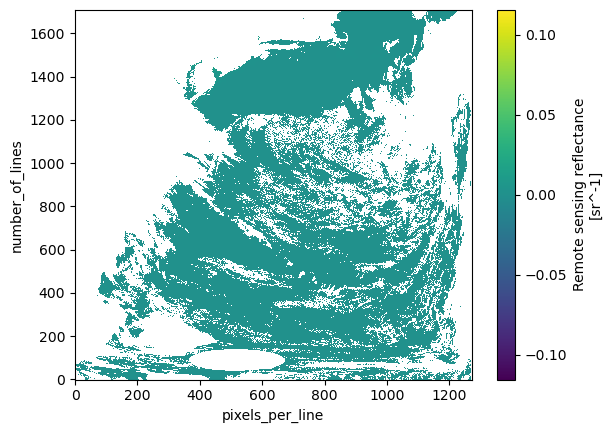

In [8]:
plot = ds["Rrs"].sel({"wavelength_3d": 100}).plot(cmap="viridis")

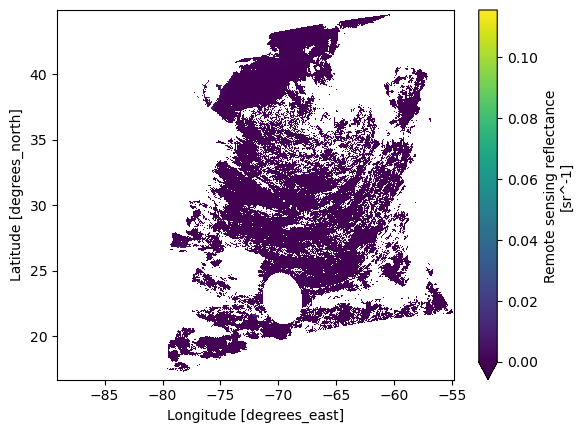

In [49]:
rrs = ds["Rrs"].sel({"wavelength_3d": 100})
plot = rrs.plot(x="longitude", y="latitude", cmap="viridis", vmin=0)

In [14]:
%%time
rrs_box = dataset.where(
    (
        (dataset["latitude"] > 38.0)
        & (dataset["latitude"] < 42.5)
        & (dataset["longitude"] > -75.5)
        & (dataset["longitude"] < -69.0)
    ),
    drop = True
)

CPU times: user 8.28 s, sys: 3.6 s, total: 11.9 s
Wall time: 38.1 s


In [17]:
rrs_box

<xarray.Dataset> Size: 182MB
Dimensions:    (number_of_lines: 491, pixels_per_line: 532, wavelength_3d: 172)
Coordinates:
    longitude  (number_of_lines, pixels_per_line) float32 1MB -75.09 ... -69.24
    latitude   (number_of_lines, pixels_per_line) float32 1MB 36.84 ... 43.39
Dimensions without coordinates: number_of_lines, pixels_per_line, wavelength_3d
Data variables:
    Rrs        (number_of_lines, pixels_per_line, wavelength_3d) float32 180MB ...
Attributes:
    long_name:      Remote sensing reflectance
    units:          sr^-1
    standard_name:  surface_ratio_of_upwelling_radiance_emerging_from_sea_wat...
    valid_min:      -30000
    valid_max:      25000

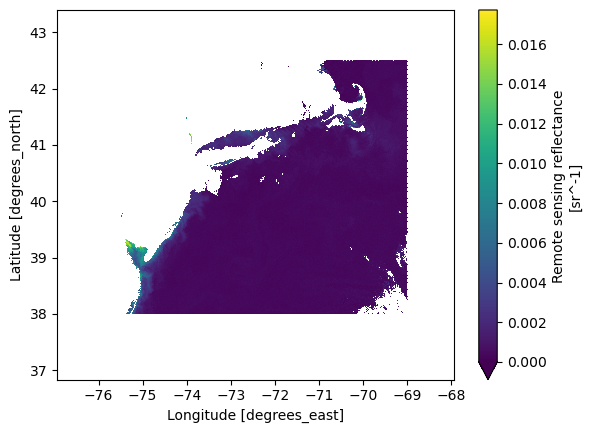

In [18]:
rrs = rrs_box["Rrs"].sel({"wavelength_3d": 100})
plot = rrs.plot(x="longitude", y="latitude", cmap="viridis", vmin=0)

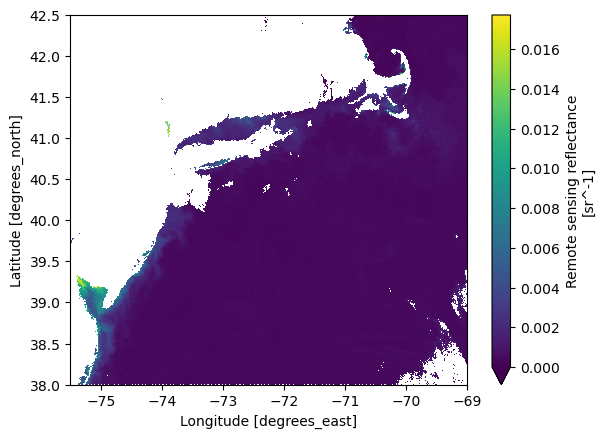

In [20]:
import matplotlib.pyplot as plt

rrs = rrs_box["Rrs"].sel({"wavelength_3d": 100})
plot = rrs.plot(x="longitude", y="latitude", cmap="viridis", vmin=0)

# Set x and y limits
plot.axes.set_xlim(-75.5, -69.0)
plot.axes.set_ylim(38.0, 42.5)

plt.show()

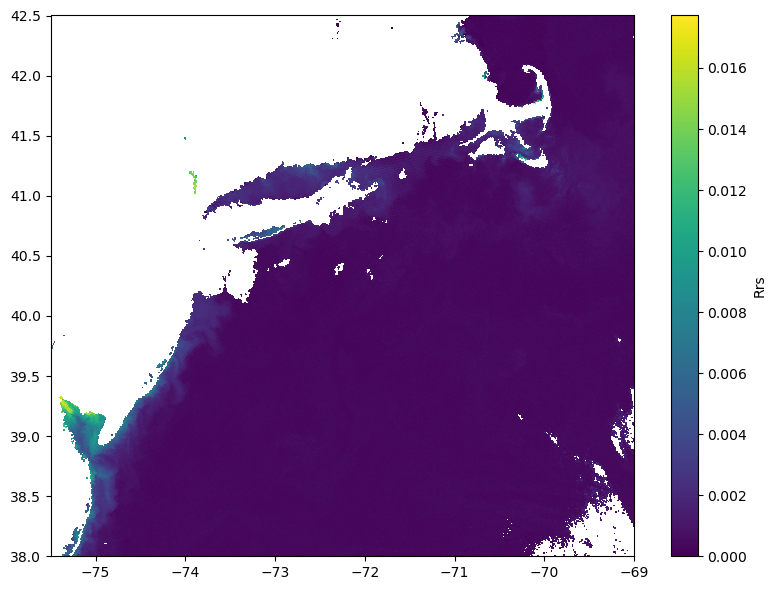

In [24]:
import matplotlib.pyplot as plt

# Extract values
lat = rrs_box['latitude'].values
lon = rrs_box['longitude'].values
rrs = rrs_box['Rrs'].sel(wavelength_3d=100).values

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))

mesh = ax.pcolormesh(lon, lat, rrs, cmap='viridis', shading='auto', vmin=0)

# Add a colorbar
plt.colorbar(mesh, ax=ax, label="Rrs")

# Set tight axis limits around data
ax.set_xlim(-75.5, -69.0)
ax.set_ylim(38.0, 42.5)

# Optional: remove squareness (equal aspect) for tight layout
ax.set_aspect('auto')

plt.tight_layout()
plt.show()


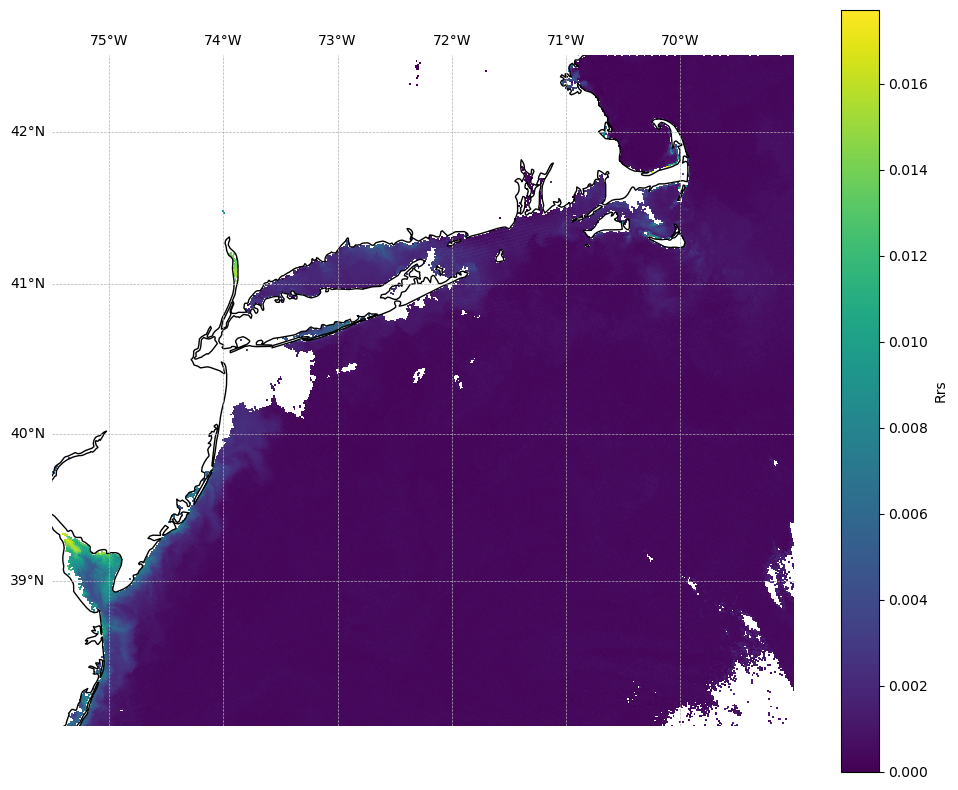

In [44]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker

# Data
lat = rrs_box['latitude'].values
lon = rrs_box['longitude'].values
rrs = rrs_box['Rrs'].sel(wavelength_3d=100).values

# Projection
#proj = ccrs.LambertConformal(central_longitude=-72.5, central_latitude=40.0)
proj = ccrs.Mercator()

# Plot
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=proj)

mesh = ax.pcolormesh(lon, lat, rrs, cmap='viridis', shading='auto', vmin=0,
                     transform=ccrs.PlateCarree())

# Features
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.BORDERS, linestyle=':')
gl = ax.gridlines(draw_labels=True, linestyle='--', linewidth=0.5)
gl.top_labels = True
gl.bottom_labels = False
gl.left_labels = True
gl.right_labels = False

# Force tick positions where you want lon labels (e.g., every 1 degree)
gl.xlocator = mticker.FixedLocator([-75, -74, -73, -72, -71, -70])

# Set extent
ax.set_extent([-75.5, -69.0, 38.0, 42.5], crs=ccrs.PlateCarree())

# Remove all box/frame/spines
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_frame_on(False)

# Colorbar
plt.colorbar(mesh, ax=ax, label="Rrs")
plt.tight_layout()
plt.show()





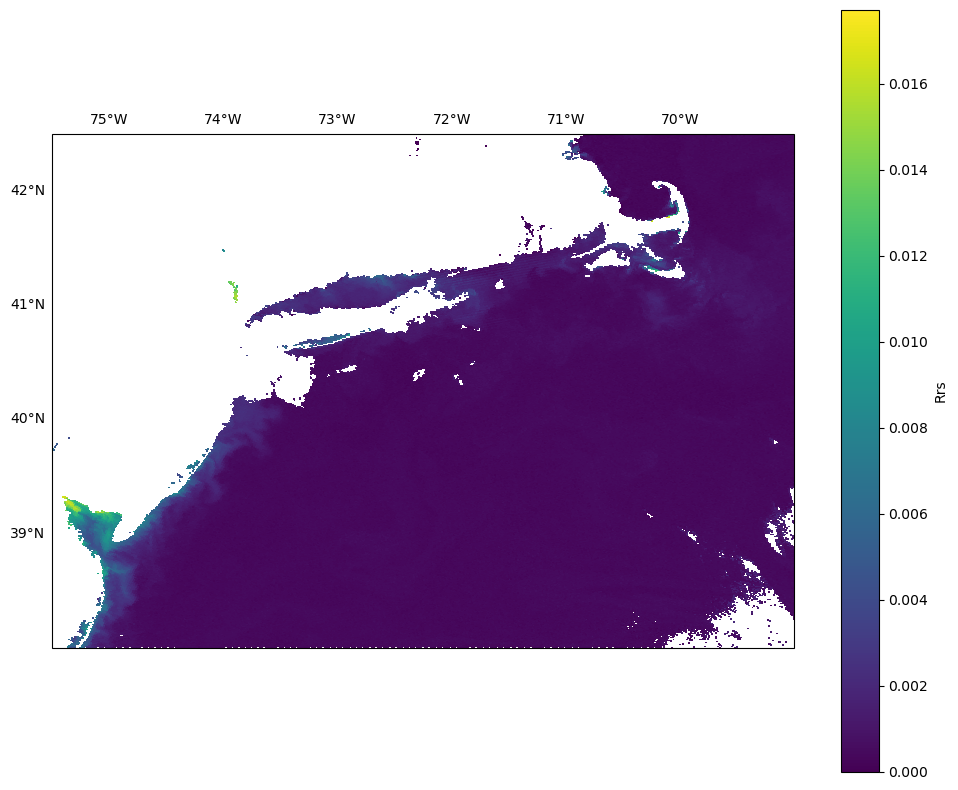

In [50]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker

# Data
lat = rrs_box['latitude'].values
lon = rrs_box['longitude'].values
rrs = rrs_box['Rrs'].sel(wavelength_3d=100).values

# Projection
#proj = ccrs.LambertConformal(central_longitude=-72.5, central_latitude=40.0)
proj = ccrs.PlateCarree()

# Plot
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=proj)

mesh = ax.pcolormesh(lon, lat, rrs, cmap='viridis', shading='auto', vmin=0,
                     transform=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True)
gl.xlines = False  
gl.ylines = False  
gl.top_labels = True
gl.bottom_labels = False
gl.left_labels = True
gl.right_labels = False

# Set extent
ax.set_extent([-75.5, -69.0, 38.0, 42.5], crs=ccrs.PlateCarree())

# Colorbar
plt.colorbar(mesh, ax=ax, label="Rrs")
plt.tight_layout()
plt.show()

In [33]:
pip install mpl_toolkits

ERROR: Could not find a version that satisfies the requirement mpl_toolkits (from versions: none)
ERROR: No matching distribution found for mpl_toolkits
Note: you may need to restart the kernel to use updated packages.


In [28]:
ds.sel(latitude=slice(38.0,42.5))

KeyError: "no index found for coordinate 'latitude'"

In [17]:
import h5netcdf
with h5netcdf.File(fileset[0]) as file:
    groups = list(file)
groups

['sensor_band_parameters',
 'scan_line_attributes',
 'geophysical_data',
 'navigation_data',
 'processing_control']

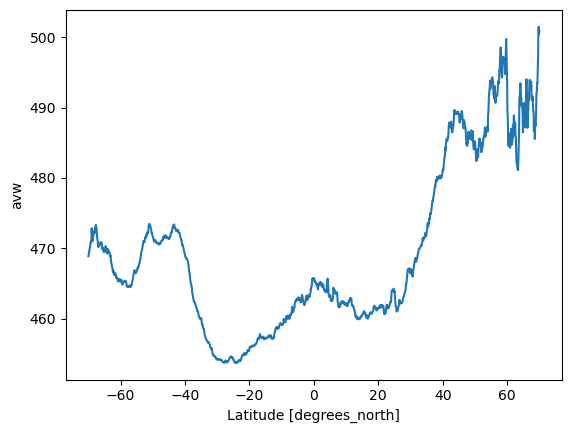

In [17]:
lat_mean = ds["avw"].sel(lat = slice(70, -70)).mean(dim=["lon"])
lat_mean.plot.line(x="lat");

### Multiple months

In [61]:
ds = xr.open_mfdataset(
    fileset,
    combine='nested', concat_dim="time"
)
ds

<xarray.Dataset> Size: 207MB
Dimensions:  (time: 8, lat: 1800, lon: 3600, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat      (lat) float32 7kB 89.95 89.85 89.75 89.65 ... -89.75 -89.85 -89.95
  * lon      (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.9 180.0
Dimensions without coordinates: time, rgb, eightbitcolor
Data variables:
    avw      (time, lat, lon) float32 207MB dask.array<chunksize=(1, 512, 1024), meta=np.ndarray>
    palette  (time, rgb, eightbitcolor) uint8 6kB dask.array<chunksize=(1, 3, 256), meta=np.ndarray>
Attributes: (12/62)
    product_name:                      PACE_OCI.20240301_20240331.L3m.MO.AVW....
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    cdm_data_type:                     grid
    identifier_product_doi_authority:  http://dx.doi.org
    identifier_product_doi:            10.5067/PACE/OCI/L3M/AVW/3.0
    data_bins:                         3016790
    data_minimum:                      399.99997
    data_maximum:                      700.00006

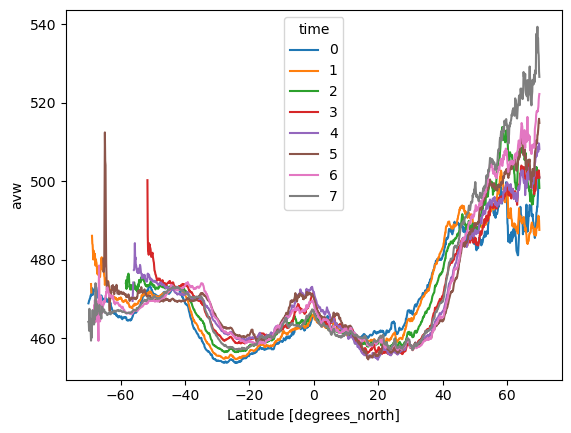

In [62]:
lat_mean = ds["avw"].sel(lat = slice(70, -70)).mean(dim=["lon"])
lat_mean.plot.line(x="lat");

## Daily data

We need the data links that have 0.1 deg and DAY in the file name.

In [18]:
import earthaccess
results_day = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_AVW",
    temporal = ("2024-03-01", "2024-03-31"),
    granule_name="*.DAY.*.0p1deg.*"
)
len(results_day)

23

In [9]:
results_day[0]

Collection: {'ShortName': 'PACE_OCI_L3M_AVW', 'Version': '3.0'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'NorthBoundingCoordinate': 90, 'SouthBoundingCoordinate': -90, 'WestBoundingCoordinate': -180, 'EastBoundingCoordinate': 180}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2024-03-05T00:00:00Z', 'EndingDateTime': '2024-03-05T23:59:59Z'}}
Size(MB): 2.2527074813842773
Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240305.L3m.DAY.AVW.V3_0.avw.0p1deg.nc']

In [10]:
# let's load the data
fileset = earthaccess.open(results_day)

QUEUEING TASKS | :   0%|          | 0/23 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/23 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/23 [00:00<?, ?it/s]

In [8]:
ds = xr.open_mfdataset(
    fileset,
    combine='nested', concat_dim="time"
)
ds

<xarray.Dataset> Size: 363MB
Dimensions:  (time: 14, lat: 1800, lon: 3600, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat      (lat) float32 7kB 89.95 89.85 89.75 89.65 ... -89.75 -89.85 -89.95
  * lon      (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.9 180.0
Dimensions without coordinates: time, rgb, eightbitcolor
Data variables:
    avw      (time, lat, lon) float32 363MB dask.array<chunksize=(1, 512, 1024), meta=np.ndarray>
    palette  (time, rgb, eightbitcolor) uint8 11kB dask.array<chunksize=(1, 3, 256), meta=np.ndarray>
Attributes: (12/62)
    product_name:                      PACE_OCI.20240305.L3m.DAY.AVW.V3_0.avw...
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    cdm_data_type:                     grid
    identifier_product_doi_authority:  http://dx.doi.org
    identifier_product_doi:            10.5067/PACE/OCI/L3M/AVW/3.0
    data_bins:                         571271
    data_minimum:                      399.99997
    data_maximum:                      700.0001

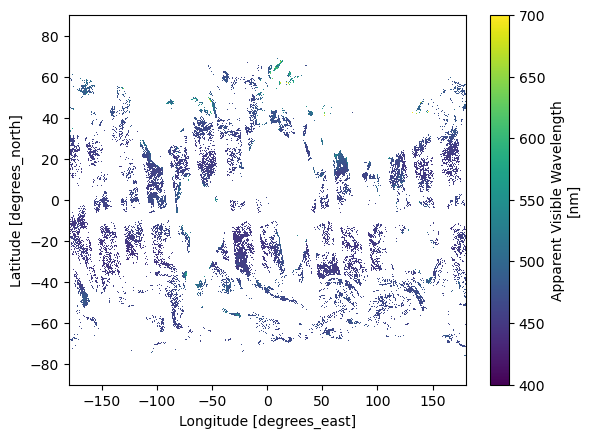

In [71]:
ds["avw"].isel(time=0).plot();

In [72]:
import matplotlib.pyplot as plt
import gc
plt.show()
plt.clf()       # Clear the current figure
plt.close()     # Close the figure window
gc.collect()    # Ask Python to free up memory


32562

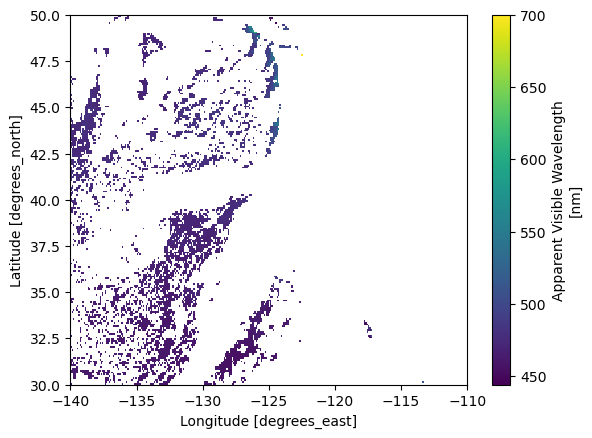

In [73]:
# let's look at the west coast of USA
ds["avw"].isel(time=0).sel(lat = slice(50, 30), lon=slice(-140, -110)).plot();

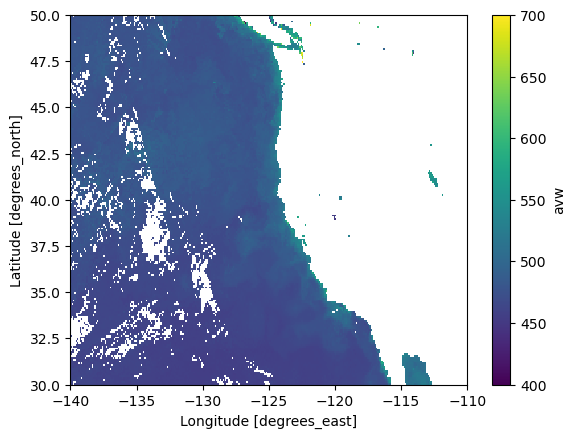

In [77]:
ds_mean = ds["avw"].mean(dim="time");
ds_mean.sel(lat = slice(50, 30), lon=slice(-140, -110)).plot();

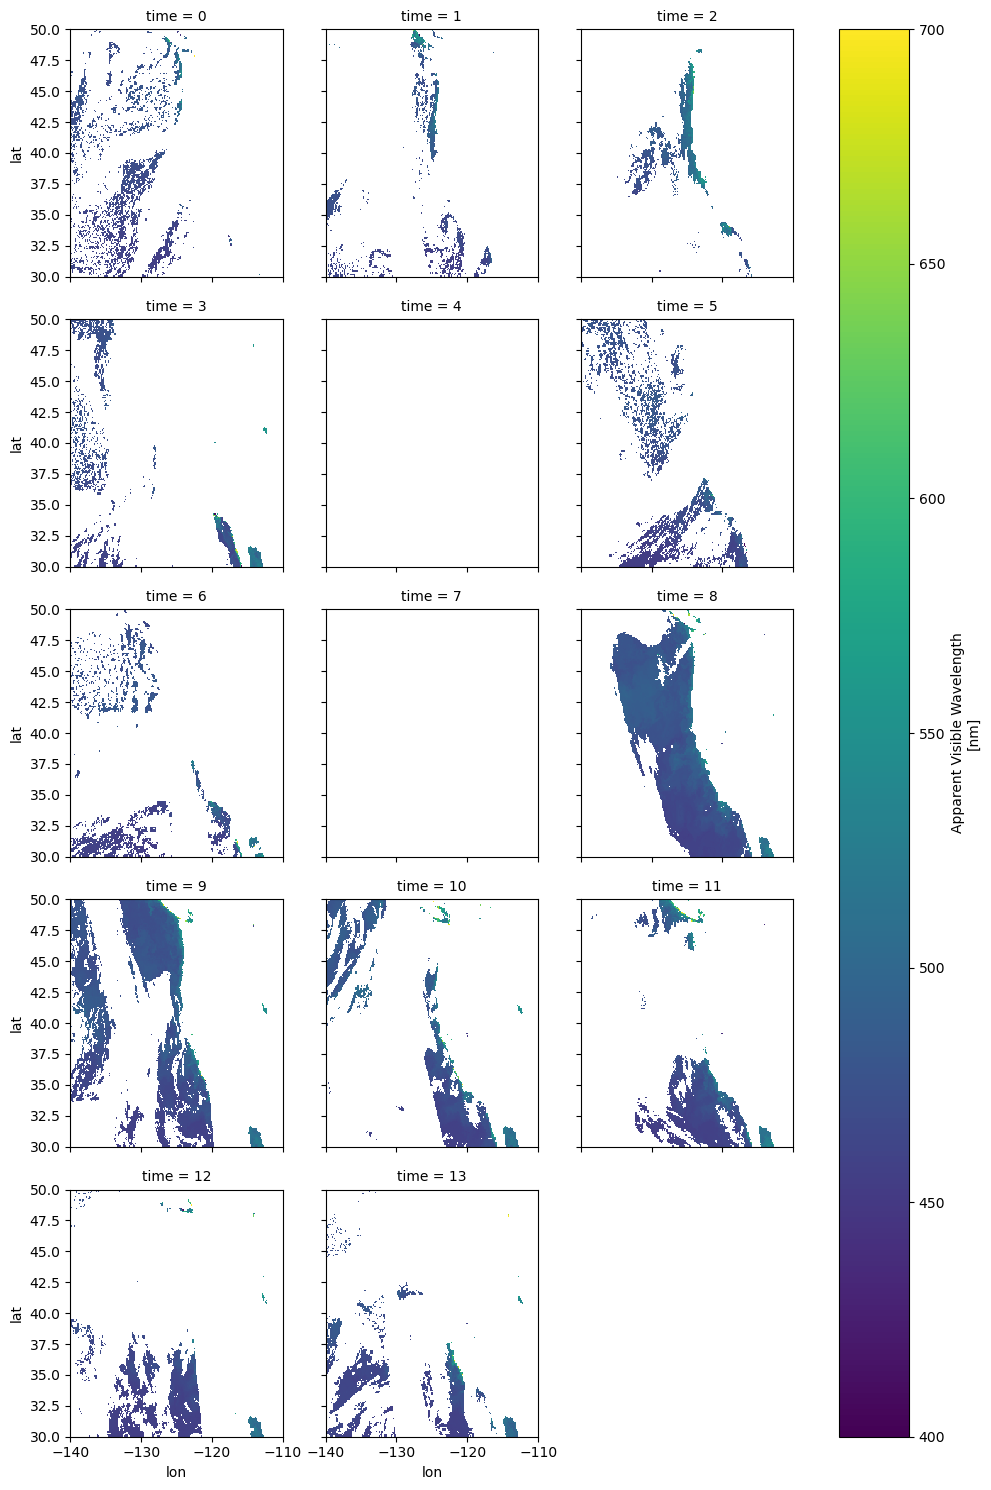

In [10]:
# We can plot over the days to see when it was cloudy
ds['avw'].sel(lat = slice(50, 30), lon=slice(-140, -110)).plot(x='lon', y='lat', col="time", col_wrap=3);

## References

* [An Introduction to Earth and Environmental Data Science](https://earth-env-data-science.github.io)
* [xarray user guide](https://docs.xarray.dev/en/stable/user-guide/index.html)